### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### Load Dataset

In [2]:
df = pd.read_csv("depression.csv")
df

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


In [3]:
print("Rows, Columns:", df.shape)

Rows, Columns: (27901, 18)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [5]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [6]:
df.columns

Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')

### Data Cleaning

In [7]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [8]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [9]:
df.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [10]:
selected_columns = [
    'Gender',
    'Age',
    'Academic Pressure',
    'Study Satisfaction',
    'Sleep Duration',
    'Dietary Habits',
    'Financial Stress',
    'Work/Study Hours',
    'Depression'
]

df = df[selected_columns].copy()

In [11]:
print(df.columns)

Index(['Gender', 'Age', 'Academic Pressure', 'Study Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Financial Stress',
       'Work/Study Hours', 'Depression'],
      dtype='object')


In [12]:
df.duplicated().sum()

732

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

0

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27169 entries, 0 to 27900
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              27169 non-null  object 
 1   Age                 27169 non-null  float64
 2   Academic Pressure   27169 non-null  float64
 3   Study Satisfaction  27169 non-null  float64
 4   Sleep Duration      27169 non-null  object 
 5   Dietary Habits      27169 non-null  object 
 6   Financial Stress    27169 non-null  float64
 7   Work/Study Hours    27169 non-null  float64
 8   Depression          27169 non-null  int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 2.1+ MB


### Exploratory Data Analysis (EDA)

#### Distribusi Target

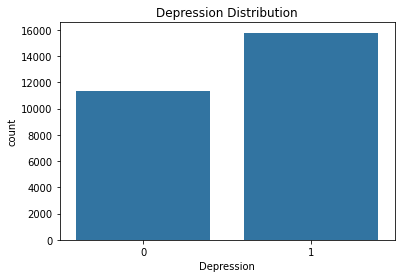

In [16]:
sns.countplot(data=df, x='Depression')
plt.title("Depression Distribution")
plt.show()

#### Gender vs Depression

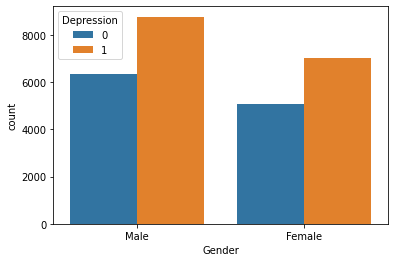

In [17]:
sns.countplot(data=df, x='Gender', hue='Depression')
plt.show()

#### Academic Pressure

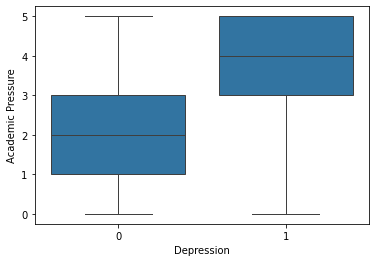

In [18]:
sns.boxplot(data=df, x='Depression', y='Academic Pressure')
plt.show()

#### Financial Stress

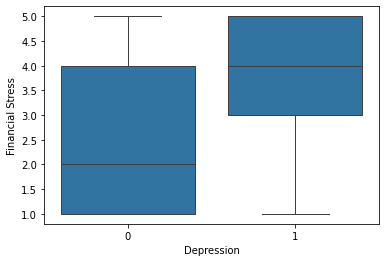

In [19]:
sns.boxplot(data=df, x='Depression', y='Financial Stress')
plt.show()

#### Age Distribution

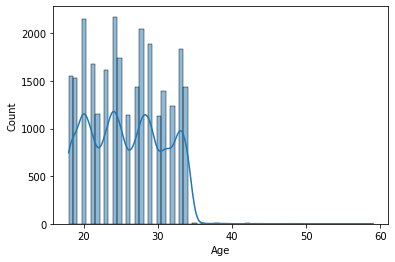

In [20]:
sns.histplot(df['Age'], kde=True)
plt.show()

### Preprocessing

In [21]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [22]:
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Financial Stress,Work/Study Hours,Depression
0,1,33.0,5.0,2.0,0,0,1.0,3.0,1
1,0,24.0,2.0,5.0,0,1,2.0,3.0,0
2,1,31.0,3.0,5.0,2,0,1.0,9.0,0
3,0,28.0,3.0,2.0,1,1,5.0,4.0,1
4,0,25.0,4.0,3.0,0,1,1.0,1.0,0


### Feature Selection

In [23]:
X = df.drop('Depression', axis=1)
y = df['Depression']

### Split Data

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)

### Decision Tree

In [25]:
dt_model = DecisionTreeClassifier(random_state=0)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [26]:
y_pred_dt = dt_model.predict(X_test)

### Evaluasi Decision Tree

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.6900993743099006
              precision    recall  f1-score   support

           0       0.63      0.64      0.64      2302
           1       0.73      0.73      0.73      3132

    accuracy                           0.69      5434
   macro avg       0.68      0.68      0.68      5434
weighted avg       0.69      0.69      0.69      5434



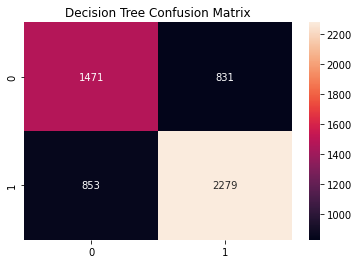

In [28]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Random Forest

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [30]:
y_pred_rf = rf_model.predict(X_test)

### Evaluasi Random Forest

In [31]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7694147957305852
              precision    recall  f1-score   support

           0       0.74      0.69      0.72      2302
           1       0.79      0.82      0.80      3132

    accuracy                           0.77      5434
   macro avg       0.77      0.76      0.76      5434
weighted avg       0.77      0.77      0.77      5434



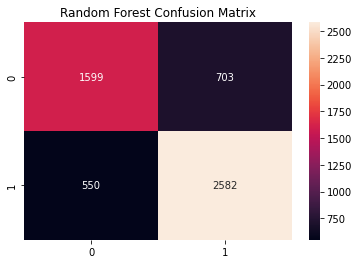

In [32]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

### Compare Model

In [33]:
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Accuracy': [dt_acc, rf_acc]
})

print(comparison)

           Model  Accuracy
0  Decision Tree  0.690099
1  Random Forest  0.769415


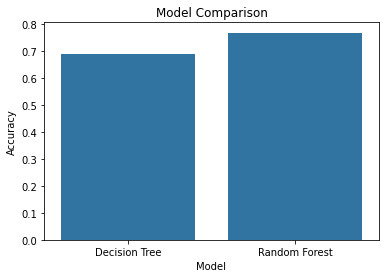

In [34]:
sns.barplot(data=comparison, x='Model', y='Accuracy')
plt.title("Model Comparison")
plt.show()

### Feature Importance

In [35]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

              Feature  Importance
2   Academic Pressure    0.228892
1                 Age    0.200831
7    Work/Study Hours    0.167614
6    Financial Stress    0.137595
3  Study Satisfaction    0.090936
4      Sleep Duration    0.080420
5      Dietary Habits    0.060143
0              Gender    0.033569


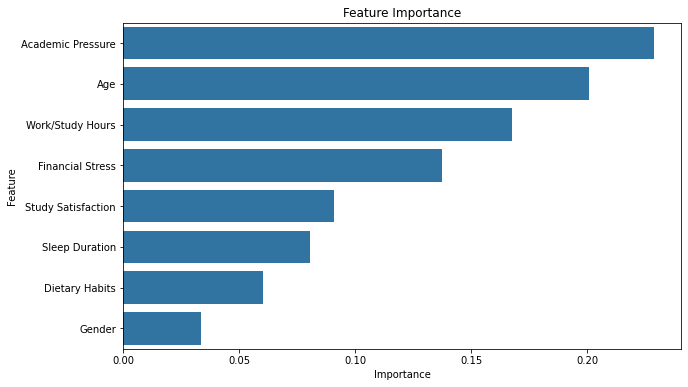

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title("Feature Importance")
plt.show()

In [37]:
import joblib

joblib.dump(rf_model, "model_depression.pkl")

['model_depression.pkl']